In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [26]:
import subprocess
from pathlib import Path

N = 100
EXE_PATH = "./tools/target/release/vis.exe"
for i in range(N):
    input_txt_path = f"./in/{str(i).zfill(4)}.txt"
    output_txt_path = f"./out/{str(i).zfill(4)}.txt"
    result_txt_path = f"./result/{str(i).zfill(4)}.txt"
    ret = subprocess.run([EXE_PATH, input_txt_path, output_txt_path, result_txt_path])

In [27]:
class Env:

    def __init__(self, input_txt_path: Path, output_txt_path, result_txt_path):
        self.W, self.D, self.N, self.a = self._input(input_txt_path)

        self.ans: list[list[int]] = []
        with open(output_txt_path, mode="r") as file:
            lines = file.readlines()
            for line in lines:
                self.ans.append(list(map(int, line.split())))

        with open(result_txt_path, mode="r") as file:
            lines = file.readlines()
            self.score = int(lines[0].strip())

    def _input(self, txt_path):
        with open(txt_path, mode="r") as file:
            lines = file.readlines()
        W, D, N = map(int, lines[0].split())
        a = []
        for line, d in zip(lines[1:], range(D)):
            d = list(map(int, line.split()))
            a.append(d)
        return W, D, N, a

In [28]:
envs = []
for i in range(N):
    input_txt_path = f"./in/{str(i).zfill(4)}.txt"
    output_txt_path = f"./out/{str(i).zfill(4)}.txt"
    result_txt_path = f"./result/{str(i).zfill(4)}.txt"
    envs.append(Env(input_txt_path, output_txt_path, result_txt_path))

In [29]:
scores = [env.score for env in envs]
ave_score = sum(scores) / N
total_score = sum(scores)

print(f"ave_score: {ave_score}, total_score: {total_score}")

ave_score: 338086.01, total_score: 33808601


In [30]:
scores

[9619,
 724175,
 254506,
 168250,
 173558,
 324126,
 32184,
 104656,
 230318,
 10640,
 148500,
 268292,
 193065,
 339543,
 373452,
 264532,
 564283,
 253774,
 153450,
 817993,
 351409,
 198670,
 161224,
 189071,
 549635,
 297760,
 36507,
 576371,
 106842,
 168590,
 157613,
 191022,
 21611,
 865987,
 1349851,
 29344,
 522525,
 124455,
 275138,
 128581,
 142060,
 108162,
 311394,
 574302,
 155803,
 838665,
 206943,
 296252,
 243441,
 281844,
 107123,
 712870,
 209405,
 548639,
 64554,
 176240,
 116376,
 552942,
 454346,
 129553,
 384701,
 762648,
 187213,
 186600,
 749698,
 211821,
 290336,
 102128,
 167836,
 147516,
 99779,
 109842,
 91269,
 63579,
 1351693,
 489753,
 1185261,
 521662,
 222556,
 475721,
 85229,
 81479,
 823950,
 82807,
 810722,
 323725,
 841811,
 122748,
 81115,
 161423,
 905470,
 92419,
 319896,
 78788,
 1085688,
 1130480,
 169219,
 40142,
 274115,
 553727]

In [31]:
ave_areas = []
for env in envs:
    sum_areas = []
    for areas in env.a:
        sum_areas.append(sum(area for area in areas) / (1000 ** 2))
    ave_areas.append(sum(sum_areas) / env.D)

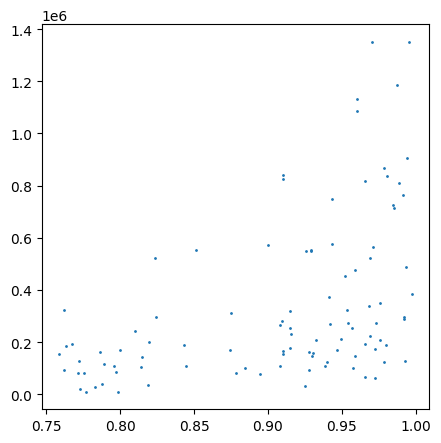

In [32]:
plt.figure(figsize=(5, 5))
plt.scatter(ave_areas, scores, s=1)
plt.show()

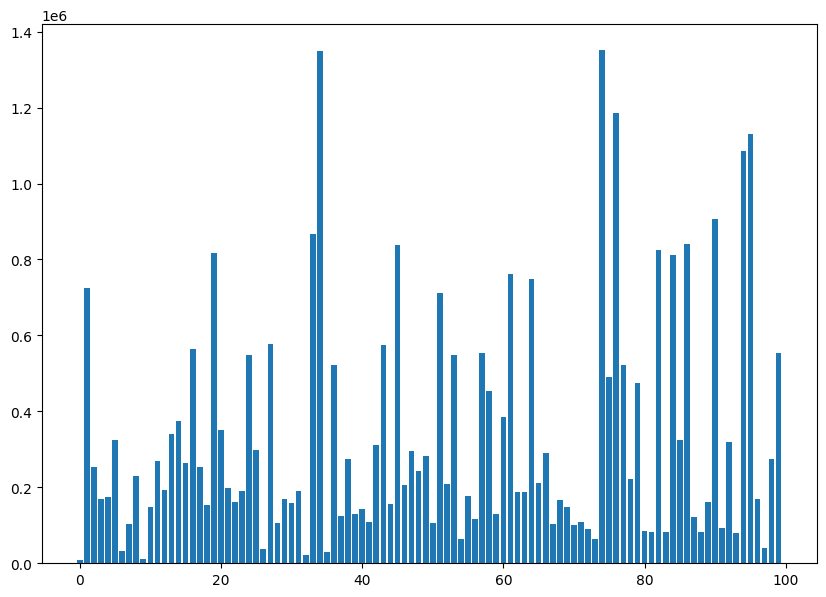

In [33]:
scores = [env.score for env in envs]
indexes = [i for i in range(N)]

plt.figure(figsize=(10, 7))
plt.bar(indexes, scores)
plt.show()

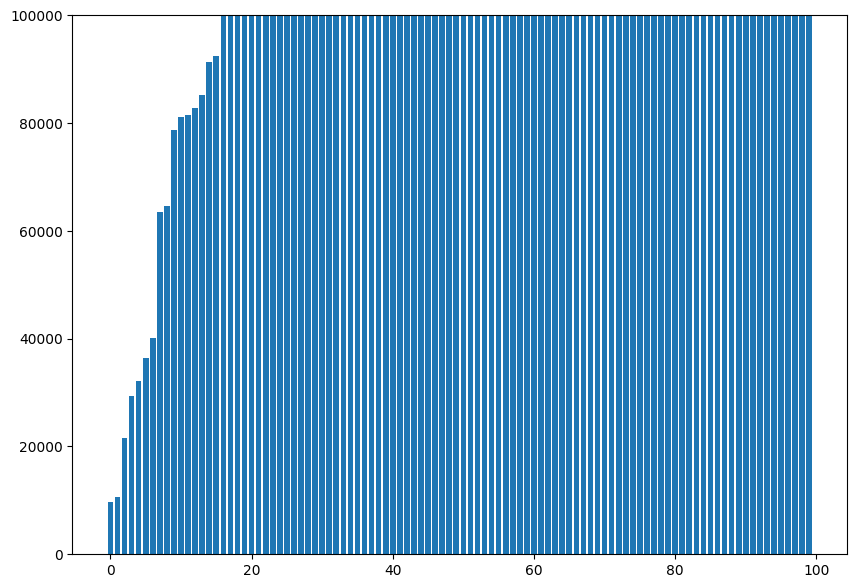

In [34]:
plt.figure(figsize=(10, 7))
plt.bar(indexes, sorted(scores))
plt.ylim(0, 10**5)
plt.show()

In [35]:
envs[0].ans[1]

[0, 772, 217, 1000]

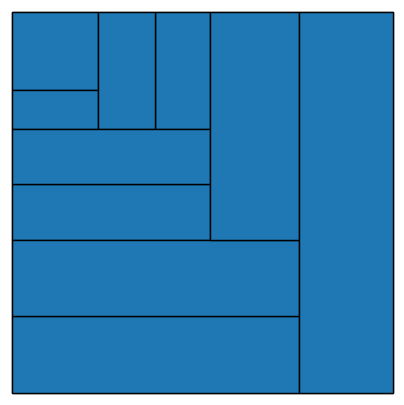

In [36]:
test_points = envs[0].ans[-envs[0].N:]

def display_map(points):
    fig = plt.figure(figsize=(5, 5))
    ax = plt.axes()

    r = patches.Rectangle(xy=(0, 0), width=1000, height=1000, ec='#000000', fill=False)
    ax.add_patch(r)

    for vec in points:
        x1, y1, x2, y2 = vec[0], vec[1], vec[2], vec[3]
        w, h = x2 - x1, y2 - y1
        r = patches.Rectangle(xy=(x1, y1), width=w, height=h, ec='#000000', fill=True)
        ax.add_patch(r)

    plt.xlim(-5, 1005)
    plt.ylim(-5, 1005)
    plt.axis('off')
    ax.set_aspect('equal')
    plt.show()

display_map(test_points)